In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display

# Pre-process Dataset

In [2]:
# Manually download dataset into /docs
# Check files/ File path
DOCS_PATH = "/content/docs"

print("Files in docs folder:", os.listdir(DOCS_PATH))

TRAIN_PATH = os.path.join(DOCS_PATH, "train.parquet")
TEST_PATH = os.path.join(DOCS_PATH, "test.parquet")

# Lazy load
train_df = pl.scan_parquet(TRAIN_PATH)
test_df = pl.scan_parquet(TEST_PATH)

# Print schema
print("Schema:")
print(test_df.schema)

# Get shape (forces minimal computation)
print("Train shape:", train_df.select(pl.count()).collect())
print("Test shape:", test_df.select(pl.count()).collect())
# Preview data (only loads small sample)
display(train_df.head(5).collect())
display(test_df.head(5).collect())

Files in docs folder: ['train.parquet', 'test.parquet']
Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Flo

/tmp/ipykernel_167533/1005924137.py:16: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(test_df.schema)
/tmp/ipykernel_167533/1005924137.py:19: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Train shape:", train_df.select(pl.count()).collect())


Train shape: shape: (1, 1)
┌─────────┐
│ count   │
│ ---     │
│ u32     │
╞═════════╡
│ 5337414 │
└─────────┘
Test shape: shape: (1, 1)
┌─────────┐
│ count   │
│ ---     │
│ u32     │
╞═════════╡
│ 1447107 │
└─────────┘


/tmp/ipykernel_167533/1005924137.py:20: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Test shape:", test_df.select(pl.count()).collect())


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [3]:
train_df = (
    pl.scan_parquet(TRAIN_PATH)
    .sort(["code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

/tmp/ipykernel_167533/3781260164.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_df = train_df.collect(streaming=True)


In [4]:
num_cols = [col for col in train_df.columns if col not in ["code", "ts_index"]]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over("code")
    .alias(col)
    for col in num_cols
])

# Median imputation
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over("code"))
    .alias(col)
    for col in num_cols
])

Summary Statistics

In [5]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061604  ┆ 2.323426  ┆

Feature Distributions

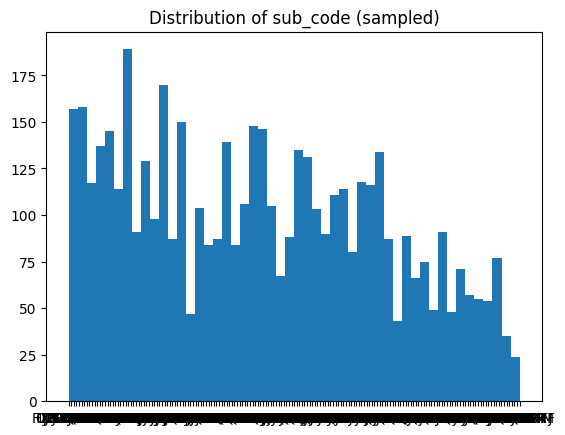

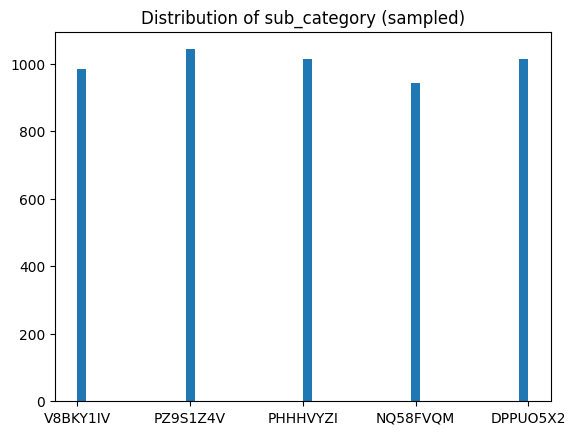

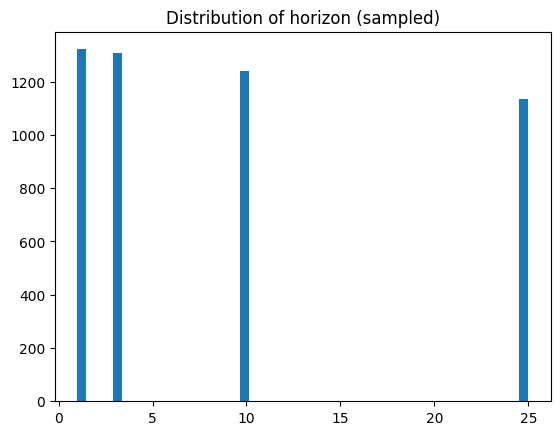

In [6]:
sample_df = train_df.select(num_cols[1:4]).sample(5000)

for col in num_cols[1:4]:
    values = sample_df[col].to_numpy()

    plt.figure()
    plt.hist(values, bins=50)
    plt.title(f"Distribution of {col} (sampled)")
    plt.show()

Volatility Check

In [7]:
# Rolling Volatility
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_std(window_size=10)
    .over("code")
    .alias("y_volatility")
])

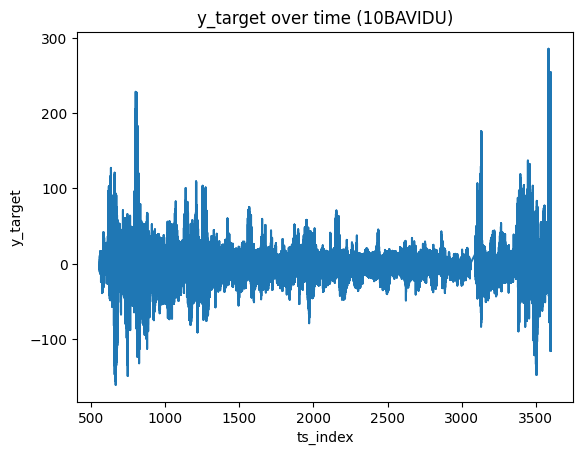

In [8]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [9]:
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_mean(window_size=10)
    .over("code")
    .alias("y_rolling_mean")
])
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""83EG83KQ__PO7LO26Y__V8BKY1IV__…","""83EG83KQ""","""PO7LO26Y""","""V8BKY1IV""",3.0,1964,14.0,10.207428,12.26135,14.692747,15.647534,5.714561,12.359249,0.016182,0.000581,0.003688,0.008013,0.073996,0.967127,0.014471,0.00135,0.044284,0.059815,0.001358,0.013546,0.171319,0.021667,0.007728,0.44346,-7.577816,-157.882491,-1.278773,0.133359,0.124407,0.072334,0.06882,0.001388,…,355.68939,891.155235,109417.059919,94994.55272,1133.10516,0.002253,1859.45733,7.168552,167.08142,96.864845,1.676045,1.348141,0.097238,0.117507,1.901008,1.091055,1.879685,-0.294429,-3.189328,-0.162454,0.124778,0.176688,3.881752,-0.002448,-0.00037,-0.000131,-0.00022,-0.011309,-0.003261,0.147141,0.024822,0.084587,0.0,0.000341,2.2086e8,0.000228,0.000201
"""OSJL3A7Y__NSYBU89B__V8BKY1IV__…","""OSJL3A7Y""","""NSYBU89B""","""V8BKY1IV""",3.0,2912,200.0,5.563125,3.172809,11.584186,10.029662,11.189841,7.017721,0.008621,0.002117,0.000029,0.000672,0.086011,4.255716,0.078668,0.0,0.008427,0.210984,0.007889,0.020739,12.61382,0.393917,12.459999,62.848638,10.273688,96.172144,-25.965798,0.0,0.11955,0.059592,0.012256,0.31056,…,1.535723,5.388066,933123.936728,7624.030914,18990.719983,0.011725,28904.796556,0.0,0.0,5149.418315,0.006761,264.690822,361.72045,8.965519,0.334557,0.005697,0.005012,-2.806721,-3.504925,-4.107071,1.41878,0.095429,4.530354,-0.052033,-0.087817,-0.059074,-0.076632,-0.005057,-0.064408,-0.032918,2.930829,0.113499,9.0,-0.587875,103.256612,0.268539,-0.319415
"""2RBMUWP1__DYJUJX3J__V8BKY1IV__…","""2RBMUWP1""","""DYJUJX3J""","""V8BKY1IV""",1.0,2131,209.0,16.105428,12.029782,3.874699,16.188358,6.498631,4.027914,0.00023,0.000553,0.004066,0.000107,1.593964,0.084481,0.059003,0.0,0.130477,0.069006,0.11955,0.181031,0.564413,1.227475,0.335679,7.118675,6.479213,1.023665,-2.548024,0.0,0.123675,0.042103,0.023399,0.704439,…,0.133931,0.691355,4846.109247,6908.847022,5592.691311,-0.000475,143543.06229,1.475795,4.417044,1.138847,0.004166,19.495173,21.062179,13.794261,0.005647,0.003318,0.006295,-0.201596,-7.10716,-3.409986,0.143604,0.092758,0.248952,-0.014709,-0.017685,-0.225401,-0.00537,-0.232638,-0.009744,-0.005996,0.109544,0.083828,2.0,-0.468344,0.794666,3.782602,1.138159
"""4KUR2ZOZ__KZSDAYZT__V8BKY1IV__…","""4KUR2ZOZ""","""KZSDAYZT""","""V8BKY1IV""",1.0,2673,56.0,4.465516,8.211779,7.897942,8.719936,4.398847,12.004875,0.007072,0.009426,0.000831,0.000148,1.956834,0.056972,-0.006082,0.001874,0.023301,0.001771,0.000616,0.035841,0.01833,0.015649,0.420594,-2.058066,-7.274545,-213.43111,-159.571382,0.066124,1.652374,0.541462,0.238939,0.000833,…,703.693971,1287.046065,286221.924308,3.4205e6,216939.394769,0.010549,3.2801e6,0.095386,90049.520669,21923.957127,0.327238,4.843177,0.260971,6.541377,7.864977,0.402337,3.969195,-0.345623,-0.268565,-3.141538,2.721721,3.306341,6.679429,-0.01663,-0.022023,-0.000229,-0.000538,-0.02116,-0.000562,-0.154015,2.557078,0.028179,1.0,-0.039845,19853.577953,0.07764,-0.012527
"""K7Y1TTAH__3US8M659__NQ58FVQM__…"

In [10]:
# Feature Importance Correlation
corr_df = train_df.select(
    [pl.corr(col, "y_target").alias(col) for col in num_cols[:10]]
)

print(corr_df)

shape: (1, 10)
┌─────┬──────────┬──────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id  ┆ sub_code ┆ sub_category ┆ horizon   ┆ … ┆ feature_c ┆ feature_d ┆ feature_e ┆ feature_f │
│ --- ┆ ---      ┆ ---          ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64 ┆ f64      ┆ f64          ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN ┆ NaN      ┆ NaN          ┆ -0.018719 ┆ … ┆ 0.00057   ┆ 0.000097  ┆ -0.000574 ┆ -0.000027 │
└─────┴──────────┴──────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


# Baseline Model

First, the necessary libraries and modules are imported for the creation of this base model, which includes using Random Forest Regressor.

In [11]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

SEED = 42

print(train_df.shape)
train_df.head()

(5337414, 96)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",3.0,3531,141.0,3.475385,15.13462,3.265031,10.380979,8.83843,2.01938,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,0.670754,0.017167,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3531,134.0,12.707232,11.597299,6.034944,13.931955,9.418021,16.584339,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,5.601772,0.010329,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",25.0,3531,119.0,11.262484,1.45387,6.210146,8.292425,1.175443,15.234003,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,8.425576,0.016712,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3531,143.0,2.296699,1.939771,15.459024,8.540194,16.673829,14.100175,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,-2.795824,0.032189,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3532,142.0,4.631196,2.84

Next, we define features and target, as well as, all other fields for appropriate feature selection.

In [12]:
TARGET = "horizon"
TS_INDEX = "ts_index"
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"

# Sort by time index
SAMPLE_FRAC = 0.01

train_df = (
    train_df
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

# Features
FEATURES = [c for c in train_df.columns if c not in [TARGET, TS_INDEX, ID, CODE, SUBCODE, SUBCATEGORY]]
FEATURES = FEATURES[:50]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)

Time-series validation splits are then defined to prevent data leakage.

---



In [13]:
# Time-series cross validation
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

splits = list(tscv.split(X))

print(f"Number of splits: {len(splits)}")

Number of splits: 5


Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [14]:
def weighted_rmse(y_true, y_pred, weights=None):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if weights is None:
        weights = np.ones_like(y_true)

    weights = np.array(weights)

    mse = np.average((y_true - y_pred) ** 2, weights=weights)
    return np.sqrt(mse)

def compute_weights(df):

    return np.ones(len(df))

Most importantly, we train the baseline random forest model.

In [15]:
def train_baseline_hgbr(X, y, splits):

    fold_scores = []
    oof_predictions = np.zeros(len(X))

    # Convert once (fastest)
    X_np = X.to_numpy()
    y_np = y.to_numpy()

    for fold, (train_idx, val_idx) in enumerate(splits):

        print(f"\n===== Fold {fold+1} =====")

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]
        y_train = y_np[train_idx]
        y_val   = y_np[val_idx].flatten() # Flatten y_val to ensure it's a 1D array

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_val)
        oof_predictions[val_idx] = preds

        score = weighted_rmse(y_val, preds)
        fold_scores.append(score)

        print(f"Fold RMSE: {score:.5f}")

        del model, X_train, X_val
        gc.collect()

    return oof_predictions, fold_scores

Here we obtain the 'error magnitude' or RMSE of each split. This shows how well the base model learns.

In [16]:
oof_preds, fold_scores = train_baseline_hgbr(X,y,splits)
print("\n======================")
print("Baseline Results")
print("======================")
print("Fold Scores:", fold_scores)
print("Mean Score:", np.mean(fold_scores))


===== Fold 1 =====
Fold RMSE: 8.28822

===== Fold 2 =====
Fold RMSE: 8.30348

===== Fold 3 =====
Fold RMSE: 8.04543

===== Fold 4 =====
Fold RMSE: 8.06589

===== Fold 5 =====
Fold RMSE: 7.98388

Baseline Results
Fold Scores: [np.float64(8.288224783417238), np.float64(8.303478455817404), np.float64(8.04542653752729), np.float64(8.065890421736597), np.float64(7.983875096980536)]
Mean Score: 8.137379059095812


Next, we evaluate the model using competition metric. We shall perform the same operations on test_df as done on train_df. The first step is to preprocess the test data.

In [17]:
# Load and collect test_df similar to train_df
test_df_processed = (
    pl.scan_parquet(TEST_PATH)
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
    .collect(streaming=True)
)

# Columns to exclude from numerical preprocessing (these are categorical or identifiers)
exclude_cols_for_num_processing = [ID, CODE, SUBCODE, SUBCATEGORY, TS_INDEX, TARGET]

# Identify feature columns for imputation (all numerical columns except those in exclude_cols_for_num_processing)
test_feature_cols = [
    col for col in test_df_processed.columns
    if col not in exclude_cols_for_num_processing and test_df_processed[col].dtype.is_numeric()
]

# Forward fill
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(CODE)
    .alias(col)
    for col in test_feature_cols
])

# Median imputation
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over(CODE))
    .alias(col)
    for col in test_feature_cols
])

# Rolling Volatility (based on TARGET 'horizon')
test_df_processed = test_df_processed.with_columns([
    pl.col(TARGET)
    .rolling_std(window_size=10)
    .over(CODE)
    .alias("y_volatility")
])

# Rolling Mean (based on TARGET 'horizon')
test_df_processed = test_df_processed.with_columns([
    pl.col(TARGET)
    .rolling_mean(window_size=10)
    .over(CODE)
    .alias("y_rolling_mean")
])

print("Processed Test DataFrame Head:")
display(test_df_processed.head())

print("\nProcessed Test DataFrame Schema:")
print(test_df_processed.schema)

Processed Test DataFrame Head:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_volatility,y_rolling_mean
str,str,str,str,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",25,4175,185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",1,4175,210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",10,4175,201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3,4175,208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3,4176,207.0,14.844531,1.652745,3.9592


Processed Test DataFrame Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Float64, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float64,

Secondly, we must select our targets & features for testing as well as preview the test.

In [18]:
# Select features and target for the test set, using the same FEATURES list as for training
X_test = test_df_processed.select(FEATURES)
y_test = test_df_processed.select(TARGET)

print("\nX_test Head:")
display(X_test.head())
print("\ny_test Head:")
display(y_test.head())


X_test Head:


feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,feature_al,feature_am,feature_an,feature_ao,feature_ap,feature_aq,feature_ar,feature_as,feature_at,feature_au,feature_av,feature_aw,feature_ax
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
207.0,14.844531,1.652745,3.959252,4.966838,3.946401,10.636208,0.001842,0.000218,0.000067,0.000089,3.230579,0.646894,2.057089,4.393155,0.691346,11.689794,0.682537,1.410798,47.797074,3.534047,0.939,2.729261,16.588922,59.151639,337.547998,0.024871,0.086148,0.021184,1.559661,0.669681,14.835492,0.548329,11.189002,0.670332,0.025856,0.247064,0.047637,170.136767,6.858543,416.39972,7.583717,0.034262,0.033196,0.084037,0.0,0.0,0.0,0.0,0.0



y_test Head:


horizon
i32
25
1
10
3
3


Finally, we must train the sample data for testing and commence testing to obtain a score based on RMSE.

In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Train a final HistGradientBoostingRegressor model on the entire (sampled) training data
print("Training final model on sampled training data...")
final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    random_state=SEED
)
# X and y are Polars DataFrames, convert to numpy for scikit-learn
final_model.fit(X.to_numpy(), y.to_numpy().flatten()) # Flatten y for 1D target

print("\nMaking predictions on test data...")
# Convert X_test to numpy for scikit-learn prediction
test_preds = final_model.predict(X_test.to_numpy())

# Calculate weights for the test set (using the same compute_weights function)
final_weights_test = compute_weights(test_df_processed)

# Evaluate the model on the test set
test_score = weighted_rmse(y_test.to_numpy().flatten(), test_preds, final_weights_test)

print(f"\nFinal Test Score (Weighted RMSE): {test_score:.5f}")

Training final model on sampled training data...

Making predictions on test data...

Final Test Score (Weighted RMSE): 8.04809
